## Install Dependencies & Load Imports

In [1]:
%pip install numpy "minari[hf]" minisom scikit-learn scipy matplotlib

import numpy as np
import minari
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load dataset

If the dataset has not been downloaded yet, Minari will fetch it automatically from the remote
registry the first time `load_dataset` is called.

In [2]:
DATASET_ID_EXPERT = "mujoco/invertedpendulum/expert-v0"
DATASET_ID_MEDIUM = "mujoco/invertedpendulum/medium-v0"

# Download if not already cached locally
if DATASET_ID_EXPERT not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_EXPERT)

dataset_expert = minari.load_dataset(DATASET_ID_EXPERT)
print(f"Dataset loaded: {DATASET_ID_EXPERT}")
print(f"Total episodes : {dataset_expert.total_episodes}")
print(f"Total steps    : {dataset_expert.total_steps}")

if DATASET_ID_MEDIUM not in minari.list_local_datasets():
    minari.download_dataset(DATASET_ID_MEDIUM)  
dataset_medium = minari.load_dataset(DATASET_ID_MEDIUM)
print(f"Dataset loaded: {DATASET_ID_MEDIUM}")
print(f"Total episodes : {dataset_medium.total_episodes}")
print(f"Total steps    : {dataset_medium.total_steps}")

Dataset loaded: mujoco/invertedpendulum/expert-v0
Total episodes : 100
Total steps    : 100000
Dataset loaded: mujoco/invertedpendulum/medium-v0
Total episodes : 1040
Total steps    : 99075


## Initialize combined numpy array for all observations

In [3]:
obs_list = []

for episode in dataset_expert.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])  # drop terminal observation

for episode in dataset_medium.iterate_episodes():
    obs = episode.observations
    obs_list.append(obs[:-1])

all_observations = np.concatenate(obs_list, axis=0)
print("all_observations shape:", all_observations.shape)

all_observations shape: (199075, 4)


## Initialize 'instruction' vector

In [4]:
# Target state is the subset of the input space where the pole is near vertical (angle close to 0)
threshold = 0.025

# Pole angle is the 3rd column (index 2) of the observations
instruction = (np.abs(all_observations[:, 2]) <= threshold).astype(np.float32).reshape(-1, 1)

print("instruction shape:", instruction.shape)
print("num ones:", int(instruction.sum()), "num zeros:", instruction.shape[0] - int(instruction.sum()))

instruction shape: (199075, 1)
num ones: 13719 num zeros: 185356


## Joint Probabilities of Observations & Instruction

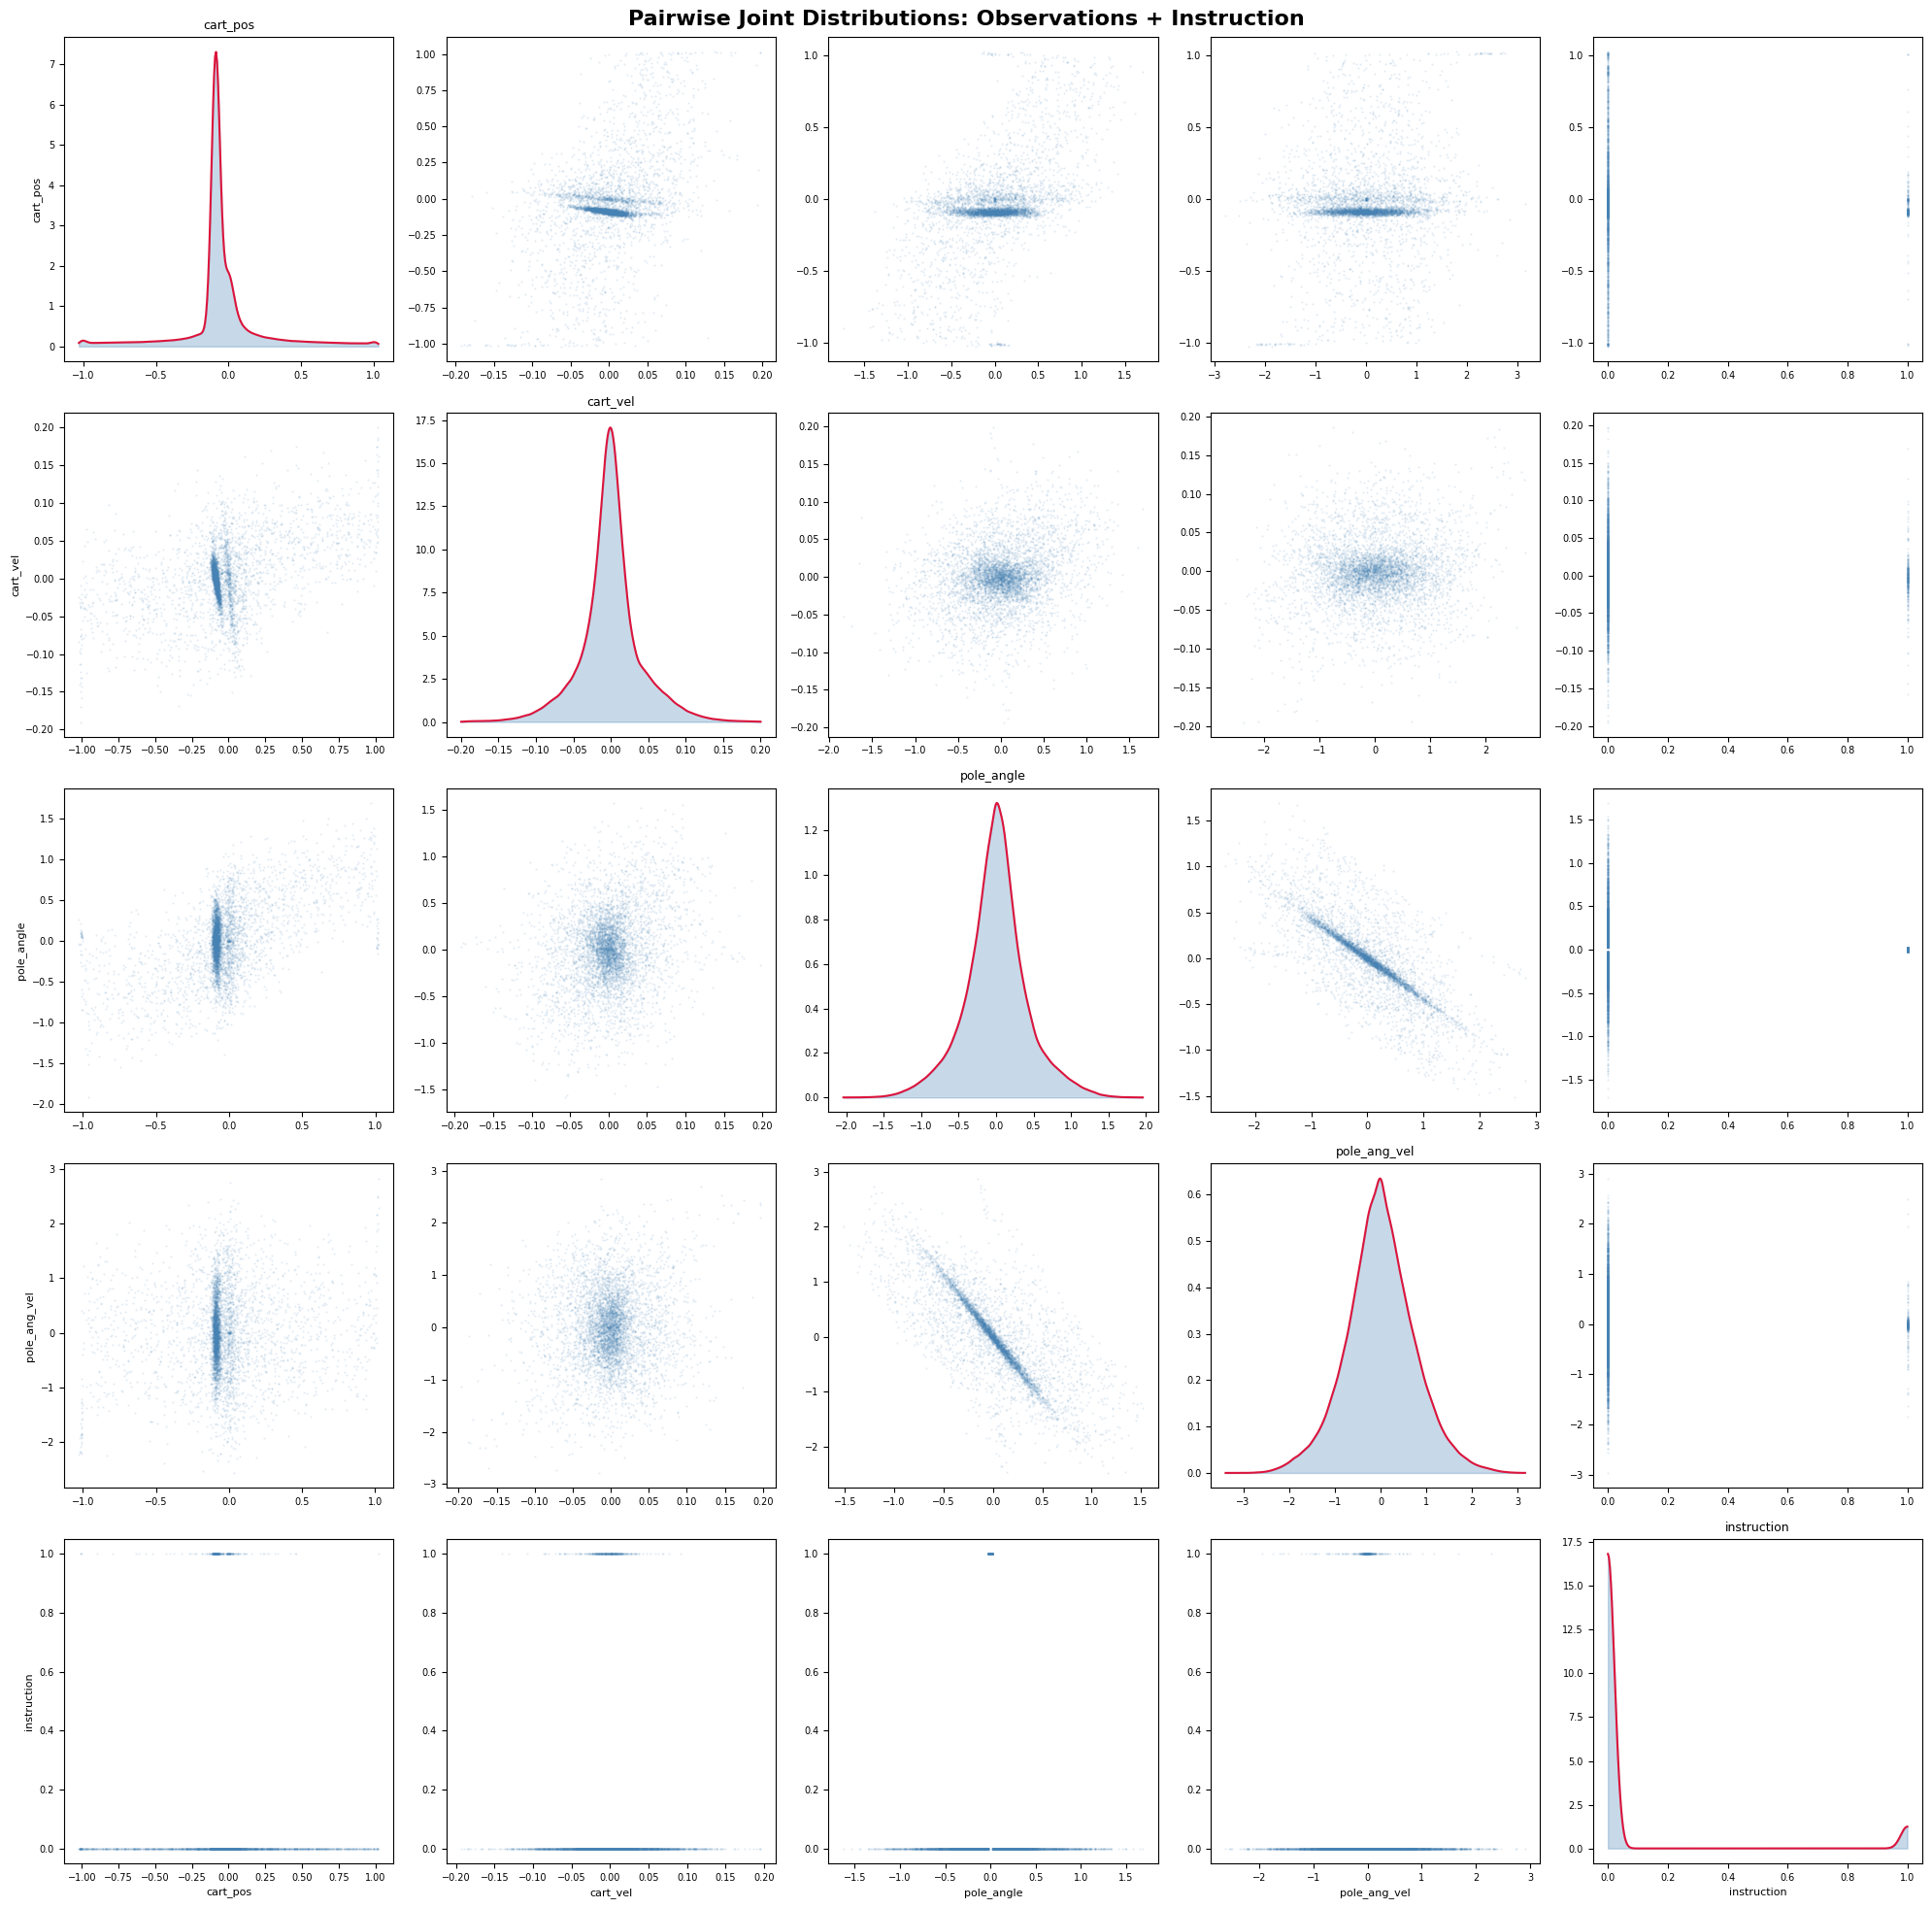

In [5]:
# Combine observations and instruction into a single matrix
all_obs_with_instruction = np.concatenate([all_observations, instruction], axis=1)
COL_NAMES_5 = ["cart_pos", "cart_vel", "pole_angle", "pole_ang_vel", "instruction"]

fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        if i == j:
            col = all_obs_with_instruction[:, i]
            kde = gaussian_kde(col)
            x = np.linspace(col.min(), col.max(), 300)
            ax.plot(x, kde(x), color="crimson")
            ax.fill_between(x, kde(x), alpha=0.3, color="steelblue")
            ax.set_title(COL_NAMES_5[i], fontsize=9)
        else:
            # Subsample for performance
            idx = np.random.choice(len(all_obs_with_instruction), size=5000, replace=False)
            ax.scatter(
                all_obs_with_instruction[idx, j],
                all_obs_with_instruction[idx, i],
                s=0.5, alpha=0.1, color="steelblue"
            )
        if i == 4:
            ax.set_xlabel(COL_NAMES_5[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(COL_NAMES_5[i], fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle("Pairwise Joint Distributions: Observations + Instruction", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Initialize Critic SOM

In [6]:
# pdf_samples refers to how many samples of each input variable PDF, which determines the resolution of the PDF map
pdf_samples_per_feature = 10

# For each column of all_observations, generate a array of size (pdf_samples_per_feature, ) to hold the weights for each input SOM.
#
# Example: if all_observations has 100,000 rows of obeservations with 4 columns per observation, and we want to generate
# a PDF map with 10 samples for each of those 4 input variables, then we will create a weights array of shape (4, 10) to 
# hold the weights for each of the 4 input variables across the 10 PDF samples. 
# Each row of this weights array corresponds to one of the input variables, and each column corresponds to one of the 
# PDF samples for that variable.
#
# Here is the algorithm for initializeing each row of weights for each input feature. 
# 1) find the max and min of each column. 
# 2) set the value of the first column of each row with the min value from the observed feature
# 3) set the value in the last column with the max value for that feature. 
# 4) calculate the values for the middle columns to be evenly separated between the max and min.

l1_weights = np.zeros((all_observations.shape[1], pdf_samples_per_feature))

for i in range(all_observations.shape[1]):
    col_min = all_observations[:, i].min()
    col_max = all_observations[:, i].max()
    l1_weights[i, 0] = col_min
    l1_weights[i, -1] = col_max
    if pdf_samples_per_feature > 2:
        step = (col_max - col_min) / (pdf_samples_per_feature - 1)
        for j in range(1, pdf_samples_per_feature - 1):
            l1_weights[i, j] = col_min + j * step

print("Initialized L1 weights shape:", l1_weights.shape)
print("L1 weights:\n", l1_weights)

# Print max and min of each column of all_observations for verification
for i in range(all_observations.shape[1]):
    print(f"Feature {i} - Min: {all_observations[:, i].min():.4f}, Max: {all_observations[:, i].max():.4f}")

# Initialize output layer activations array to hold the activations of each of the PDF samples for each input variable.
l1_activations = np.zeros((all_observations.shape[1], pdf_samples_per_feature))

Initialized L1 weights shape: (4, 10)
L1 weights:
 [[-1.02977948 -0.80078254 -0.5717856  -0.34278866 -0.11379173  0.11520521
   0.34420215  0.57319909  0.80219602  1.03119296]
 [-0.19995233 -0.15551388 -0.11107543 -0.06663697 -0.02219852  0.02223993
   0.06667838  0.11111683  0.15555528  0.19999373]
 [-2.03657518 -1.59264509 -1.14871499 -0.7047849  -0.26085481  0.18307529
   0.62700538  1.07093548  1.51486557  1.95879567]
 [-3.38455838 -2.65768553 -1.93081268 -1.20393983 -0.47706698  0.24980587
   0.97667872  1.70355157  2.43042443  3.15729728]]
Feature 0 - Min: -1.0298, Max: 1.0312
Feature 1 - Min: -0.2000, Max: 0.2000
Feature 2 - Min: -2.0366, Max: 1.9588
Feature 3 - Min: -3.3846, Max: 3.1573


## Training/Testing Data Splitting Function

In [7]:
# 80/20 train-test split is the default, but we can adjust the split ratio if desired
def train_test_split(all_observations, instruction, split_ratio=0.8):
    split_idx = int(len(all_observations) * split_ratio)
    shuffled_idx = np.random.permutation(len(all_observations))
    training_idx = shuffled_idx[:split_idx]
    testing_idx = shuffled_idx[split_idx:]
    return (
        all_observations[training_idx],
        all_observations[testing_idx],
        instruction[training_idx],
        instruction[testing_idx]
    )

## Critic SOM Update Algorithm

In [8]:
def update_critsom(observation, W, lr, sigma):
    """
    Update critic SOM weights and post-synaptic map.

    Parameters
    ----------
    observation : np.ndarray, shape (1, num_features) or (num_features,)
    W           : np.ndarray, shape (num_features, pdf_samples_per_feature)
    lr          : scalar
    sigma       : scalar

    Returns
    -------
    W, bmu : updated arrays and list of BMU index tuples
    """
    if observation.ndim == 1:
        observation = observation.reshape(1, -1)

    num_features, pdf_samples_per_feature = W.shape
    bmu_indices = []

    for i in range(num_features):
        # Compute distances from the observation to each PDF sample for this feature
        distances = np.abs(observation[0, i] - W[i, :])
        bmu_idx = np.argmin(distances)
        bmu_indices.append((i, bmu_idx))

        # Update weights using Gaussian neighborhood function
        for j in range(pdf_samples_per_feature):
            dist_to_bmu = np.abs(j - bmu_idx)
            neighborhood_factor = np.exp(- (dist_to_bmu ** 2) / (2 * (sigma ** 2)))
            W[i, j] += lr * neighborhood_factor * (observation[0, i] - W[i, j])

    return W, bmu_indices

## Critic SOM Training Loop Function

In [9]:
def train_critsom(training_observations, lr, sigma, num_episodes, l1_weights):
    # Assemble tiled training_observations based on the number of episodes
    tiled_observations = np.tile(training_observations, (num_episodes, 1))
    T = len(tiled_observations)
    
    # For each observation, update each individual of l1_weights using the value of that feature in the observation.
    # The learing rate and eighborhood radius sigma are decreased  as the training progresses, such that the updates are only 10% of the original value by the end of training.
    for t, obs in enumerate(tiled_observations):
        lr_t = lr * (0.1 ** (t / T))
        sigma_t = sigma * (0.1 ** (t / T))
        l1_weights, bmu_indices = update_critsom(obs, l1_weights, lr_t, sigma_t)


## Train & Test Critic SOM

Initial L1 weights shape: (4, 10)
Initial L1 weights:
 [[-1.02977948 -0.80078254 -0.5717856  -0.34278866 -0.11379173  0.11520521  0.34420215  0.57319909  0.80219602  1.03119296]
 [-0.19995233 -0.15551388 -0.11107543 -0.06663697 -0.02219852  0.02223993  0.06667838  0.11111683  0.15555528  0.19999373]
 [-2.03657518 -1.59264509 -1.14871499 -0.7047849  -0.26085481  0.18307529  0.62700538  1.07093548  1.51486557  1.95879567]
 [-3.38455838 -2.65768553 -1.93081268 -1.20393983 -0.47706698  0.24980587  0.97667872  1.70355157  2.43042443  3.15729728]]
Training complete.
Final learned weights after training:
Feature 0 weights: [-0.90052763 -0.6377519  -0.39022026 -0.21701959 -0.08182488  0.01954182  0.15911316  0.32916612  0.5648487   0.89824264]
Feature 1 weights: [-0.12458274 -0.07940516 -0.05111305 -0.02498806 -0.00918322  0.0064607   0.0225744   0.04974556  0.08530808  0.13517379]
Feature 2 weights: [-1.16538598 -0.74050253 -0.49331011 -0.24782749 -0.07497537  0.05657666  0.2097559   0.464057

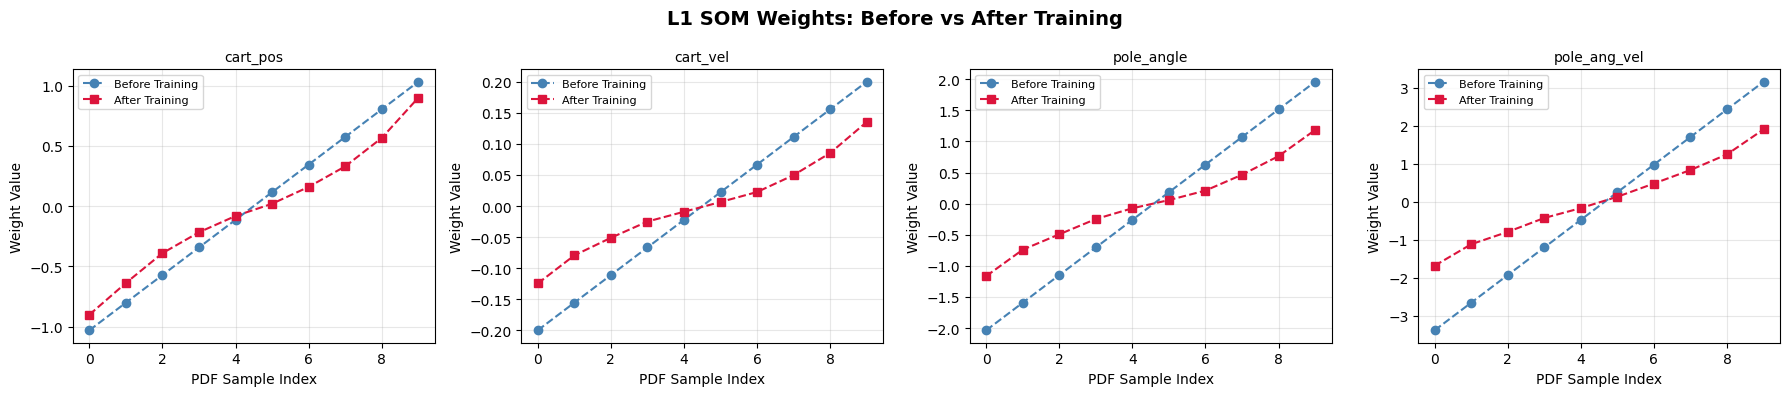

In [14]:
# --- Split data ---
training_observations, testing_observations, training_instruction, testing_instruction = train_test_split(
    all_observations, instruction, split_ratio=0.9
)

# --- Re-initialize L1 weights ---
for i in range(all_observations.shape[1]):
    col_min = all_observations[:, i].min()
    col_max = all_observations[:, i].max()
    l1_weights[i, 0] = col_min
    l1_weights[i, -1] = col_max
    if pdf_samples_per_feature > 2:
        step = (col_max - col_min) / (pdf_samples_per_feature - 1)
        for j in range(1, pdf_samples_per_feature - 1):
            l1_weights[i, j] = col_min + j * step
initial_l1_weights = l1_weights.copy()
np.set_printoptions(linewidth=np.inf)
print("Initial L1 weights shape:", initial_l1_weights.shape)
print("Initial L1 weights:\n", initial_l1_weights)

# --- Train Critic SOM ---
initial_lr = 0.5
initial_sigma = 3.0
num_episodes = 1
train_critsom(training_observations, initial_lr, initial_sigma, num_episodes, l1_weights)
print("Training complete.")
print("Final learned weights after training:")
for i in range(all_observations.shape[1]):
    print(f"Feature {i} weights: {l1_weights[i]}")

fig, axes = plt.subplots(1, all_observations.shape[1], figsize=(18, 4))

for i in range(all_observations.shape[1]):
    ax = axes[i]
    ax.plot(initial_l1_weights[i], 'o--', label='Before Training', color='steelblue')
    ax.plot(l1_weights[i], 's--', label='After Training', color='crimson')
    ax.set_title(COL_NAMES_4[i], fontsize=10)
    ax.set_xlabel("PDF Sample Index")
    ax.set_ylabel("Weight Value")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("L1 SOM Weights: Before vs After Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



In [56]:
COL_NAMES_4 = ["cart_pos", "cart_vel", "pole_angle", "pole_ang_vel"]

# Select a random test observation
rand_idx = np.random.randint(0, len(testing_observations))
test_obs = testing_observations[rand_idx]

print("Selected observation:")
for i, (name, val) in enumerate(zip(COL_NAMES_4, test_obs)):
    print(f"  {name}: {val:.6f}")

print("\nBMU indices and weight values per feature:")
for i, name in enumerate(COL_NAMES_4):
    distances = np.abs(test_obs[i] - l1_weights[i, :])
    bmu = np.argmin(distances)
    print(f"  {name}: BMU index = {bmu}, weight value = {l1_weights[i, bmu]:.6f} (obs value = {test_obs[i]:.6f})")

Selected observation:
  cart_pos: -0.071697
  cart_vel: 0.018081
  pole_angle: -0.192639
  pole_ang_vel: 0.284589

BMU indices and weight values per feature:
  cart_pos: BMU index = 4, weight value = -0.081825 (obs value = -0.071697)
  cart_vel: BMU index = 6, weight value = 0.022574 (obs value = 0.018081)
  pole_angle: BMU index = 3, weight value = -0.247827 (obs value = -0.192639)
  pole_ang_vel: BMU index = 5, weight value = 0.130244 (obs value = 0.284589)
